In [1]:
import pandas as pd

# Load the raw CTG dataset
file_path = "../data/raw/CTG.xls"

ctg_data = pd.read_excel(
    file_path,
    sheet_name="Data",
    header=1
)

print("Dataset loaded successfully!")
print("Shape:", ctg_data.shape)

Dataset loaded successfully!
Shape: (2129, 46)


In [2]:
print("Column names:")
print(ctg_data.columns.tolist())

Column names:
['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'Unnamed: 9', 'LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'Unnamed: 31', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'Unnamed: 42', 'CLASS', 'Unnamed: 44', 'NSP']


In [3]:
features = [
    "LB", "AC.1", "FM.1", "UC.1",
    "DL.1", "DS.1", "DP.1",
    "ASTV", "MSTV", "ALTV", "MLTV",
    "Width", "Min", "Max", "Nmax", "Nzeros",
    "Mode", "Mean", "Median", "Variance", "Tendency"
]

target = "NSP"

ml_data = ctg_data[features + [target]].copy()

print("ML dataset shape:", ml_data.shape)
print("\nML columns:")
print(ml_data.columns.tolist())

ML dataset shape: (2129, 22)

ML columns:
['LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'NSP']


In [4]:
print("Missing values per column:")
print(ml_data.isnull().sum())

print("\nTotal missing values:")
print(ml_data.isnull().sum().sum())

Missing values per column:
LB          3
AC.1        3
FM.1        2
UC.1        2
DL.1        1
DS.1        1
DP.1        1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
NSP         3
dtype: int64

Total missing values:
54


In [5]:
# Find rows where the target (NSP) is missing
invalid_rows = ml_data[ml_data["NSP"].isna()]

print("Rows with missing NSP:")
display(invalid_rows)

Rows with missing NSP:


,LB,AC.1,FM.1,UC.1,DL.1,DS.1,DP.1,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaN,0.480634,0.014925,0.015385,0.001353,0.005348,87.0,7.0,91.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Remove rows without a target label
ml_data = ml_data.dropna(subset=["NSP"]).reset_index(drop=True)

print("Shape after removing invalid rows:", ml_data.shape)
print("\nMissing values after removing invalid rows:")
print(ml_data.isnull().sum().sum())

Shape after removing invalid rows: (2126, 22)

Missing values after removing invalid rows:
0


In [7]:
# Check for exact duplicate rows
duplicate_count = ml_data.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 12


In [8]:
# Remove exact duplicate rows
ml_data = ml_data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", ml_data.shape)
print("Duplicate rows remaining:", ml_data.duplicated().sum())

Shape after removing duplicates: (2114, 22)
Duplicate rows remaining: 0


In [9]:
# Save cleaned dataset
clean_path = "../data/processed/fetal_health_clean.csv"

ml_data.to_csv(clean_path, index=False)

print("Clean dataset saved successfully!")
print("Path:", clean_path)

Clean dataset saved successfully!
Path: ../data/processed/fetal_health_clean.csv


In [10]:
# Check target class distribution
class_counts = ml_data["NSP"].value_counts().sort_index()

print("Fetal Health Class Distribution:")
print(class_counts)

print("\nClass percentages:")
print((class_counts / len(ml_data) * 100).round(2))

Fetal Health Class Distribution:
NSP
1.0    1647
2.0     292
3.0     175
Name: count, dtype: int64

Class percentages:
NSP
1.0    77.91
2.0    13.81
3.0     8.28
Name: count, dtype: float64


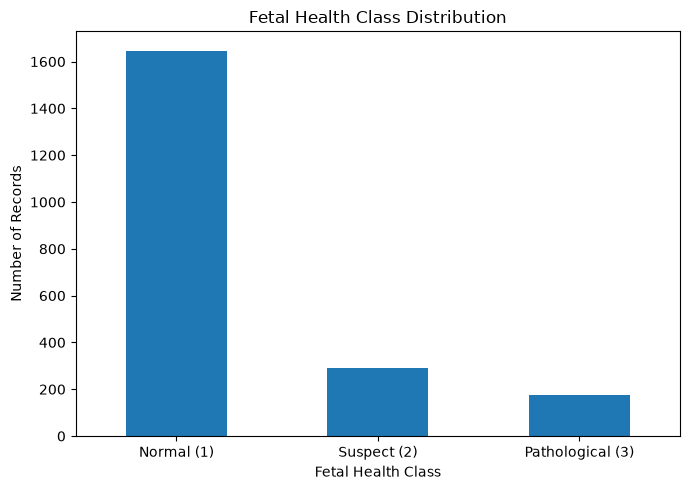

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

class_counts.plot(kind="bar")

plt.title("Fetal Health Class Distribution")
plt.xlabel("Fetal Health Class")
plt.ylabel("Number of Records")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Normal (1)", "Suspect (2)", "Pathological (3)"],
    rotation=0
)

plt.tight_layout()

# Save figure for report/PPT
plt.savefig("../results/figures/class_distribution.png", dpi=300)

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = ml_data[features]
y = ml_data["NSP"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1691, 21)
Testing set: (423, 21)


In [13]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Scaling completed!
Training data shape: (1691, 21)
Testing data shape: (423, 21)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=1000,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

results_df = pd.DataFrame(results).sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print(results_df)

c:\Users\kirth\OneDrive\Desktop\SEM 5\ML\fetal-health-ctg-classification\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


                 Model  Accuracy  Macro F1  Weighted F1
0    Gradient Boosting  0.957447  0.928063     0.955671
1        Random Forest  0.940898  0.900876     0.940898
2        Decision Tree  0.929078  0.879193     0.928070
3                  MLP  0.926714  0.854588     0.922766
4                  SVM  0.893617  0.838790     0.901793
5  Logistic Regression  0.874704  0.796666     0.883206
6                  KNN  0.895981  0.788265     0.889762


In [15]:
from sklearn.metrics import classification_report

# Select our best trained model
best_model = models["Gradient Boosting"]

# Predict the unseen test data
y_pred_gb = best_model.predict(X_test_scaled)

# Detailed performance for each class
print("Gradient Boosting - Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=["Normal", "Suspect", "Pathological"]
    )
)

Gradient Boosting - Classification Report

              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97       330
     Suspect       0.94      0.76      0.84        58
Pathological       0.97      0.97      0.97        35

    accuracy                           0.96       423
   macro avg       0.96      0.91      0.93       423
weighted avg       0.96      0.96      0.96       423



Confusion Matrix:
[[327   3   0]
 [ 13  44   1]
 [  1   0  34]]


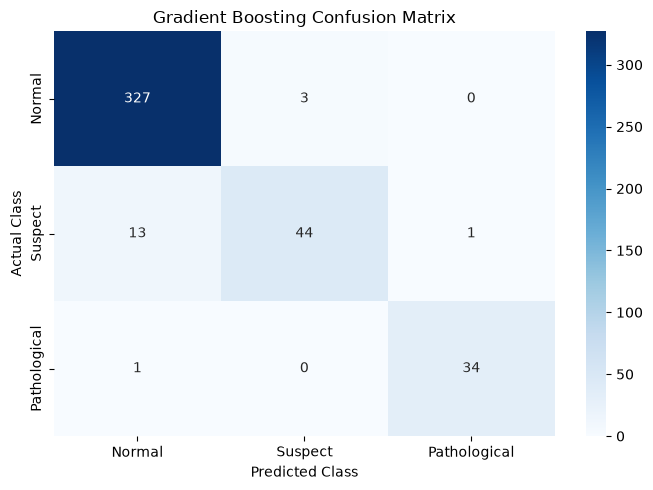

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Suspect", "Pathological"],
    yticklabels=["Normal", "Suspect", "Pathological"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

# Save for report/PPT
plt.savefig(
    "../results/figures/gradient_boosting_confusion_matrix.png",
    dpi=300
)

plt.show()

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Hyperparameter combinations to test
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

# 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

# Train and search for the best combination
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation Macro F1:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Best cross-validation Macro F1:
0.9056


In [18]:
from sklearn.metrics import accuracy_score, f1_score

# Best model found by GridSearchCV
tuned_model = grid_search.best_estimator_

# Predictions on unseen test data
y_pred_tuned = tuned_model.predict(X_test_scaled)

# Tuned model performance
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_macro_f1 = f1_score(y_test, y_pred_tuned, average="macro")
tuned_weighted_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print("Accuracy:", round(tuned_accuracy, 4))
print("Macro F1:", round(tuned_macro_f1, 4))
print("Weighted F1:", round(tuned_weighted_f1, 4))

print("\nOriginal Gradient Boosting Macro F1:", round(
    f1_score(y_test, y_pred_gb, average="macro"), 4
))

Tuned Gradient Boosting Results
--------------------------------
Accuracy: 0.9574
Macro F1: 0.9281
Weighted F1: 0.9557

Original Gradient Boosting Macro F1: 0.9281


ROC-AUC Results
----------------
Normal AUC: 0.9783
Suspect AUC: 0.9547
Pathological AUC: 0.9993
Macro ROC-AUC: 0.9775


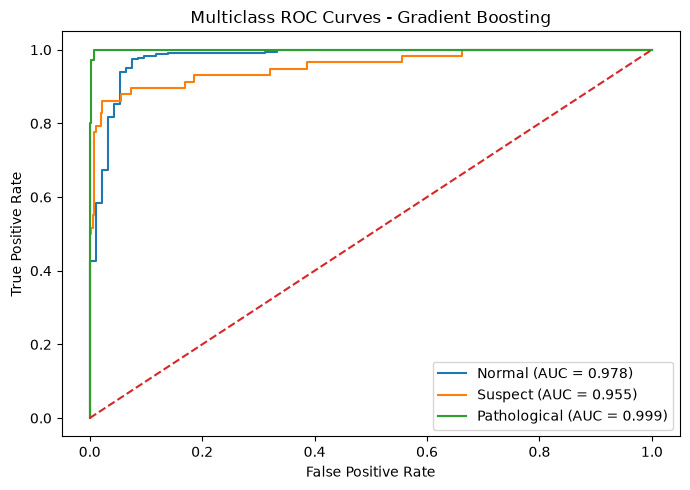

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Convert test labels to one-vs-rest format
y_test_binary = label_binarize(y_test, classes=[1, 2, 3])

# Get prediction probabilities
y_prob = tuned_model.predict_proba(X_test_scaled)

# Calculate ROC curves
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        y_prob[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC-AUC
macro_auc = roc_auc_score(
    y_test_binary,
    y_prob,
    average="macro",
    multi_class="ovr"
)

print("ROC-AUC Results")
print("----------------")
print("Normal AUC:", round(roc_auc[0], 4))
print("Suspect AUC:", round(roc_auc[1], 4))
print("Pathological AUC:", round(roc_auc[2], 4))
print("Macro ROC-AUC:", round(macro_auc, 4))

# Plot ROC curves
plt.figure(figsize=(7, 5))

class_names = ["Normal", "Suspect", "Pathological"]

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves - Gradient Boosting")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/figures/gradient_boosting_roc_curve.png",
    dpi=300
)

plt.show()

In [20]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save final model
joblib.dump(tuned_model, "../models/fetal_health_gradient_boosting.pkl")

# Save scaler
joblib.dump(scaler, "../models/fetal_health_scaler.pkl")

print("Final model saved successfully!")
print("Scaler saved successfully!")

Final model saved successfully!
Scaler saved successfully!


In [21]:
results_df.to_csv("../results/metrics/model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [22]:
# Select one real record from the test set
sample_index = 0

sample_features = X_test.iloc[[sample_index]]
actual_class = y_test.iloc[sample_index]

# Predict using the final saved model
sample_scaled = scaler.transform(sample_features)
predicted_class = tuned_model.predict(sample_scaled)[0]

class_names = {
    1: "Normal",
    2: "Suspect",
    3: "Pathological"
}

print("Actual class:   ", actual_class, "-", class_names[actual_class])
print("Predicted class:", predicted_class, "-", class_names[predicted_class])

Actual class:    1.0 - Normal
Predicted class: 1.0 - Normal
